# DevOps2 — HW2 — Ansible-роль для PostgreSQL

## Выполнил Соломонов ЕЮ, МНАД, 2 курс, @esolomonov, eysolomonov@edu.hse.ru

Оборудование: Windows 10 + WSL -> Oracle VirtualBox Ubuntu 26.04 LTS (Bridge-connection)

⚠️ Не использовался `ansible.cfg`, поскольку папка с ДЗ находилась в директории Windows => ansible.cfg не работал из-за конфликта прав.

# Подготовка

Был создан ssh-ключ. Было произведено копирование публичного ключа на Virtual Box и проверка подключения (успешно).

🖨️ Вывод:

egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ssh -i ~/.ssh/ansible_rsa devops@192.168.0.23

Enter passphrase for key '/home/egor/.ssh/ansible_rsa': 

Welcome to Ubuntu 26.04.1 LTS (GNU/Linux 7.0.0-38-generic x86_64)

 * Documentation:  https://docs.ubuntu.com
 * Management:     https://landscape.canonical.com
 * Support:        https://ubuntu.com/pro

 System information as of Mon Oct  5 11:58:00 AM UTC 2026

  System load:  0.16               Processes:               117
  Usage of /:   44.6% of 11.21GB   Users logged in:         0
  Memory usage: 17%                IPv4 address for enp0s3: 192.168.0.23
  Swap usage:   0%


Expanded Security Maintenance for Applications is not enabled.

21 updates can be applied immediately.
To see these additional updates run: apt list --upgradable

Enable ESM Apps to receive additional future security updates.
See https://ubuntu.com/esm or run: sudo pro status


Last login: Mon Oct  5 11:55:00 2026 from 192.168.0.10

devops@ubuntu-server:~$ exit

logout

Connection to 192.168.0.23 closed.

Был установлен ansible, согласно документации.

In [ ]:
$ sudo apt update
$ sudo apt install software-properties-common
$ sudo add-apt-repository --yes --update ppa:ansible/ansible
$ sudo apt install ansible

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ sudo apt install software-properties-common</pre>
<pre>Reading package lists... Done</pre>
<pre>Building dependency tree... Done</pre>
<pre>Reading state information... Done</pre>
<pre>The following additional packages will be installed:</pre>
<pre>  python3-software-properties</pre>
<pre>The following packages will be upgraded:</pre>
<pre>  python3-software-properties software-properties-common</pre>
<pre>2 upgraded, 0 newly installed, 0 to remove and 77 not upgraded.</pre>
<pre>Need to get 42.9 kB of archives.</pre>
<pre>After this operation, 5120 B of additional disk space will be used.</pre>
<pre>Do you want to continue? [Y/n] y</pre>
<pre>Abort.</pre>

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ sudo add-apt-repository --yes --update ppa:ansible/</pre>
<pre></pre>
<pre>Repository: 'deb https://ppa.launchpadcontent.net/ansible/ansible/ubuntu/ jammy main'</pre>
<pre>Description:</pre>
<pre>Ansible is a radically simple IT automation platform that makes your applications and systems easier to deploy. Avoid writing </pre>scripts or <pre>custom code to deploy and update your applications— automate in a language that approaches plain English, using SSH, with </pre>no agents to <pre>install on remote systems.</pre>
<pre></pre>
<pre>http://ansible.com/</pre>
<pre></pre>
<pre>If you face any issues while installing Ansible PPA, file an issue here:</pre>
<pre>https://github.com/ansible-community/ppa/issues</pre>
<pre>More info: https://launchpad.net/~ansible/+archive/ubuntu/ansible</pre>
<pre>Adding repository.</pre>
<pre>Adding deb entry to /etc/apt/sources.list.d/ansible-ubuntu-ansible-jammy.list</pre>
<pre>Adding disabled deb-src entry to /etc/apt/sources.list.d/ansible-ubuntu-ansible-jammy.list</pre>
<pre>Adding key to /etc/apt/trusted.gpg.d/ansible-ubuntu-ansible.gpg with fingerprint 6125E2A8C77F2818FB7BD15B93C4A3FD7BB9C367</pre>
<pre>Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease</pre>
<pre>Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                                                                    </pre>
<pre>Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports </pre><pre>InRelease                                                                                   </pre>
<pre>Hit:4 http://security.ubuntu.com/ubuntu jammy-security </pre><pre>InRelease                                                                                   </pre>
<pre>Get:5 https://download.docker.com/linux/ubuntu jammy InRelease [48.5 kB]                                                             </pre>
<pre>Get:6 https://ppa.launchpadcontent.net/ansible/ansible/ubuntu jammy InRelease [18.0 kB]                        </pre>
<pre>Hit:7 https://ppa.launchpadcontent.net/redislabs/redis/ubuntu jammy InRelease</pre>
<pre>Get:8 https://ppa.launchpadcontent.net/ansible/ansible/ubuntu jammy/main amd64 Packages [1124 B]</pre>
<pre>Get:9 https://ppa.launchpadcontent.net/ansible/ansible/ubuntu jammy/main Translation-en [752 B]</pre>
<pre>Fetched 68.4 kB in 1s (48.7 kB/s)       </pre>
<pre>Reading package lists... Done</pre>
<pre>W: Target Packages (stable/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/</pre><pre>sources.list.d/docker.sources:1</pre>
<pre>W: Target Packages (stable/binary-all/Packages) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/</pre><pre>sources.list.d/docker.sources:1</pre>
<pre>W: Target Translations (stable/i18n/Translation-en) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/</pre>apt/<pre>sources.list.d/docker.sources:1</pre>
<pre>W: Target CNF (stable/cnf/Commands-amd64) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/sources.</pre>list.<pre>d/docker.sources:1</pre>
<pre>W: Target CNF (stable/cnf/Commands-all) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/sources.</pre>list.d/<pre>docker.sources:1</pre>
<pre>W: Target Packages (stable/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/</pre><pre>sources.list.d/docker.sources:1</pre>
<pre>W: Target Packages (stable/binary-all/Packages) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/</pre><pre>sources.list.d/docker.sources:1</pre>
<pre>W: Target Translations (stable/i18n/Translation-en) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/</pre>apt/<pre>sources.list.d/docker.sources:1</pre>
<pre>W: Target CNF (stable/cnf/Commands-amd64) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/sources.</pre>list.<pre>d/docker.sources:1</pre>
<pre>W: Target CNF (stable/cnf/Commands-all) is configured multiple times in /etc/apt/sources.list.d/docker.list:1 and /etc/apt/sources.</pre>list.d/<pre>docker.sources:1</pre>

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ sudo apt install ansible</pre>
<pre>Reading package lists... Done</pre>
<pre>Building dependency tree... Done</pre>
<pre>Reading state information... Done</pre>
<pre>The following additional packages will be installed:</pre>
<pre>  ansible-core python-babel-localedata python3-babel python3-bcrypt python3-jinja2 python3-jmespath python3-kerberos python3-markupsafe</pre>
<pre>  python3-nacl python3-ntlm-auth python3-packaging python3-paramiko python3-requests-kerberos python3-requests-ntlm python3-resolvelib</pre>
<pre>  python3-winrm python3-xmltodict sshpass</pre>
<pre>Suggested packages:</pre>
<pre>  python-jinja2-doc python-nacl-doc python3-gssapi python3-invoke</pre>
<pre>The following NEW packages will be installed:</pre>
<pre>  ansible ansible-core python-babel-localedata python3-babel python3-bcrypt python3-jinja2 python3-jmespath python3-kerberos python3-markupsafe</pre>
<pre>  python3-nacl python3-ntlm-auth python3-packaging python3-paramiko python3-requests-kerberos python3-requests-ntlm python3-resolvelib</pre>
<pre>  python3-winrm python3-xmltodict sshpass</pre>
<pre>0 upgraded, 19 newly installed, 0 to remove and 79 not upgraded.</pre>
<pre>Need to get 24.5 MB of archives.</pre>
<pre>After this operation, 242 MB of additional disk space will be used.</pre>
<pre>Do you want to continue? [Y/n] y</pre>
<pre>Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 python-babel-localedata all 2.8.0+dfsg.1-7 [4982 kB]</pre>
<pre>Get:2 https://ppa.launchpadcontent.net/ansible/ansible/ubuntu jammy/main amd64 ansible-core all 2.17.14-1ppa~jammy [1017 kB]</pre>
<pre>Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 python3-babel all 2.8.0+dfsg.1-7 [85.1 kB]</pre>
<pre>Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 python3-markupsafe amd64 2.0.1-2build1 [12.7 kB]</pre>
<pre>Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-jinja2 all 3.0.3-1ubuntu0.4 [108 kB]</pre>
<pre>Get:6 http://archive.ubuntu.com/ubuntu jammy/main amd64 python3-packaging all 21.3-1 [30.7 kB]</pre>
<pre>Get:7 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-resolvelib all 0.8.1-1 [23.6 kB]</pre>
<pre>Get:8 http://archive.ubuntu.com/ubuntu jammy/main amd64 python3-jmespath all 0.10.0-1 [21.7 kB]</pre>
<pre>Get:9 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-kerberos amd64 1.1.14-3.1build5 [23.0 kB]</pre>
<pre>Get:10 http://archive.ubuntu.com/ubuntu jammy/main amd64 python3-nacl amd64 1.5.0-2 [63.1 kB]</pre>
<pre>Get:11 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-ntlm-auth all 1.4.0-1 [20.4 kB]</pre>
<pre>Get:12 http://archive.ubuntu.com/ubuntu jammy/main amd64 python3-bcrypt amd64 3.2.0-1build1 [32.7 kB]</pre>
<pre>Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-paramiko all 2.9.3-0ubuntu1.3 [134 kB]</pre>
<pre>Get:14 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-requests-kerberos all 0.12.0-2 [11.9 kB]</pre>
<pre>Get:15 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-requests-ntlm all 1.1.0-1.1 [6160 B]</pre>
<pre>Get:16 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-xmltodict all 0.12.0-2 [12.6 kB]</pre>
<pre>Get:17 http://archive.ubuntu.com/ubuntu jammy/universe amd64 python3-winrm all 0.3.0-2 [21.7 kB]</pre>
<pre>Get:18 http://archive.ubuntu.com/ubuntu jammy/universe amd64 sshpass amd64 1.09-1 [11.7 kB]</pre>
<pre>Get:19 https://ppa.launchpadcontent.net/ansible/ansible/ubuntu jammy/main amd64 ansible all 10.7.0-1ppa~jammy [17.9 MB]</pre>
<pre>Fetched 24.5 MB in 8s (2970 kB/s)                                                                                                                  </pre>
<pre>Selecting previously unselected package python-babel-localedata.</pre>
<pre>(Reading database ... 34449 files and directories currently installed.)</pre>
<pre>Preparing to unpack .../00-python-babel-localedata_2.8.0+dfsg.1-7_all.deb ...</pre>
<pre>Unpacking python-babel-localedata (2.8.0+dfsg.1-7) ...</pre>
<pre>Selecting previously unselected package python3-babel.</pre>
<pre>Preparing to unpack .../01-python3-babel_2.8.0+dfsg.1-7_all.deb ...</pre>
<pre>Unpacking python3-babel (2.8.0+dfsg.1-7) ...</pre>
<pre>Selecting previously unselected package python3-markupsafe.</pre>
<pre>Preparing to unpack .../02-python3-markupsafe_2.0.1-2build1_amd64.deb ...</pre>
<pre>Unpacking python3-markupsafe (2.0.1-2build1) ...</pre>
<pre>Selecting previously unselected package python3-jinja2.</pre>
<pre>Preparing to unpack .../03-python3-jinja2_3.0.3-1ubuntu0.4_all.deb ...</pre>
<pre>Unpacking python3-jinja2 (3.0.3-1ubuntu0.4) ...</pre>
<pre>Selecting previously unselected package python3-packaging.</pre>
<pre>Preparing to unpack .../04-python3-packaging_21.3-1_all.deb ...</pre>
<pre>Unpacking python3-packaging (21.3-1) ...</pre>
<pre>Selecting previously unselected package python3-resolvelib.</pre>
<pre>Preparing to unpack .../05-python3-resolvelib_0.8.1-1_all.deb ...</pre>
<pre>Unpacking python3-resolvelib (0.8.1-1) ...</pre>
<pre>Selecting previously unselected package ansible-core.</pre>
<pre>Preparing to unpack .../06-ansible-core_2.17.14-1ppa~jammy_all.deb ...</pre>
<pre>Unpacking ansible-core (2.17.14-1ppa~jammy) ...</pre>
<pre>Selecting previously unselected package ansible.</pre>
<pre>Preparing to unpack .../07-ansible_10.7.0-1ppa~jammy_all.deb ...</pre>
<pre>Unpacking ansible (10.7.0-1ppa~jammy) ...</pre>
<pre>Selecting previously unselected package python3-jmespath.</pre>
<pre>Preparing to unpack .../08-python3-jmespath_0.10.0-1_all.deb ...</pre>
<pre>Unpacking python3-jmespath (0.10.0-1) ...</pre>
<pre>Selecting previously unselected package python3-kerberos.</pre>
<pre>Preparing to unpack .../09-python3-kerberos_1.1.14-3.1build5_amd64.deb ...</pre>
<pre>Unpacking python3-kerberos (1.1.14-3.1build5) ...</pre>
<pre>Selecting previously unselected package python3-nacl.</pre>
<pre>Preparing to unpack .../10-python3-nacl_1.5.0-2_amd64.deb ...</pre>
<pre>Unpacking python3-nacl (1.5.0-2) ...</pre>
<pre>Selecting previously unselected package python3-ntlm-auth.</pre>
<pre>Preparing to unpack .../11-python3-ntlm-auth_1.4.0-1_all.deb ...</pre>
<pre>Unpacking python3-ntlm-auth (1.4.0-1) ...</pre>
<pre>Selecting previously unselected package python3-bcrypt.</pre>
<pre>Preparing to unpack .../12-python3-bcrypt_3.2.0-1build1_amd64.deb ...</pre>
<pre>Unpacking python3-bcrypt (3.2.0-1build1) ...</pre>
<pre>Selecting previously unselected package python3-paramiko.</pre>
<pre>Preparing to unpack .../13-python3-paramiko_2.9.3-0ubuntu1.3_all.deb ...</pre>
<pre>Unpacking python3-paramiko (2.9.3-0ubuntu1.3) ...</pre>
<pre>Selecting previously unselected package python3-requests-kerberos.</pre>
<pre>Preparing to unpack .../14-python3-requests-kerberos_0.12.0-2_all.deb ...</pre>
<pre>Unpacking python3-requests-kerberos (0.12.0-2) ...</pre>
<pre>Selecting previously unselected package python3-requests-ntlm.</pre>
<pre>Preparing to unpack .../15-python3-requests-ntlm_1.1.0-1.1_all.deb ...</pre>
<pre>Unpacking python3-requests-ntlm (1.1.0-1.1) ...</pre>
<pre>Selecting previously unselected package python3-xmltodict.</pre>
<pre>Preparing to unpack .../16-python3-xmltodict_0.12.0-2_all.deb ...</pre>
<pre>Unpacking python3-xmltodict (0.12.0-2) ...</pre>
<pre>Selecting previously unselected package python3-winrm.</pre>
<pre>Preparing to unpack .../17-python3-winrm_0.3.0-2_all.deb ...</pre>
<pre>Unpacking python3-winrm (0.3.0-2) ...</pre>
<pre>Selecting previously unselected package sshpass.</pre>
<pre>Preparing to unpack .../18-sshpass_1.09-1_amd64.deb ...</pre>
<pre>Unpacking sshpass (1.09-1) ...</pre>
<pre>Setting up python3-ntlm-auth (1.4.0-1) ...</pre>
<pre>Setting up python3-bcrypt (3.2.0-1build1) ...</pre>
<pre>Setting up python3-resolvelib (0.8.1-1) ...</pre>
<pre>Setting up python3-kerberos (1.1.14-3.1build5) ...</pre>
<pre>Setting up python3-markupsafe (2.0.1-2build1) ...</pre>
<pre>Setting up sshpass (1.09-1) ...</pre>
<pre>Setting up python-babel-localedata (2.8.0+dfsg.1-7) ...</pre>
<pre>Setting up python3-xmltodict (0.12.0-2) ...</pre>
<pre>Setting up python3-packaging (21.3-1) ...</pre>
<pre>Setting up python3-jmespath (0.10.0-1) ...</pre>
<pre>Setting up python3-requests-kerberos (0.12.0-2) ...</pre>
<pre>Setting up python3-nacl (1.5.0-2) ...</pre>
<pre>Setting up python3-requests-ntlm (1.1.0-1.1) ...</pre>
<pre>Setting up python3-babel (2.8.0+dfsg.1-7) ...</pre>
<pre>update-alternatives: using /usr/bin/pybabel-python3 to provide /usr/bin/pybabel (pybabel) in auto mode</pre>
<pre>Setting up python3-jinja2 (3.0.3-1ubuntu0.4) ...</pre>
<pre>Setting up python3-winrm (0.3.0-2) ...</pre>
<pre>Setting up python3-paramiko (2.9.3-0ubuntu1.3) ...</pre>
<pre>Setting up ansible-core (2.17.14-1ppa~jammy) ...</pre>
<pre>Setting up ansible (10.7.0-1ppa~jammy) ...</pre>
<pre>Processing triggers for man-db (2.10.2-1) ...</pre>

# Шаг 0

➡️ <i>Напишите роль для установки PostgreSQL и плейбук.</i>

Роль получила название postgres. Роль была подключена через postgres.play.yml.

In [ ]:
- name: Установка и настройка PostgreSQL
  hosts: vm1
  become: true

  vars_files:
  - ./inventories/main/group_vars/vault.yml
  
  roles:
    - postgres

Первые 2 команды относятся к установке необходимых пакетов. `acl` требуется для нормальной работы chmod, тогда как о необходимости установки `python3-psycopg2` сообщил сам ansible.

In [ ]:
- name: Шаг № 0.1 — Установка acl
  apt:
    name: acl
    state: present
    update_cache: true

- name: Шаг № 0.2 — Установка python3-psycopg2
  apt:
    name: python3-psycopg2
    state: present
    update_cache: true

# Шаг 1

➡️ <i>Установка PostgreSQL (из стандартных репозиториев Ubuntu, без подключения deb-репозиториев PostgreSQL) — из таблицы.</i>

In [ ]:
- name: Шаг № 1.1 — Установка PostgreSQL
  apt:
    name: postgresql
    state: present
    update_cache: true

- name: Шаг № 1.2 — Запуск PostgreSQL
  service:
    name: postgresql
    state: started
    enabled: true

# Шаг 2

➡️ <i>Каталоги с данными (каталог данных — параметр роли, по умолчанию /data/postgres/data) — из таблицы.</i>

In [ ]:
- name: Шаг № 2 — Каталоги с данными
  file: 
    path: "{{ __postgres_data_dir }}"
    state: directory
    owner: postgres
    group: postgres
    mode: '0700'

# Шаг 3

➡️ <i>Первичная инициализация (командой pg_ctl initdb -D $PGDATA, идемпотентно) — из таблицы.</i>

In [ ]:
- name: Шаг № 3 — Первичная инициализация
  become: true
  ansible.builtin.command:
    cmd: "sudo -u postgres {{__postgres_pgctl_dir}} initdb -D {{ __postgres_data_dir }}"
    creates: "{{ __postgres_data_dir }}/PG_VERSION"

# Шаг 4

➡️ <i>$PGDATA/postgresql.conf (параметры конфигурации принимаются словарём) — из таблицы.</i>

In [ ]:
- name: Шаг № 4 — $PGDATA/postgresql.conf — Задать postgresql.conf
  ansible.builtin.lineinfile:
    path: "{{ __postgres_data_dir }}/postgresql.conf"
    regexp: "^#?\\s*{{ item.key }}\\s*="
    line: "{{ item.key }} = {{ item.value }}"
  loop: "{{ postgres__config | dict2items }}"
  notify: psql restart

Код обработчика `psql restart`.

In [ ]:
- name: psql restart
  ansible.builtin.service:
    name: postgresql
    state: restarted

# Шаг 5

➡️ <i>$PGDATA/pg_hba.conf (правила авторизации принимаются списком словарей) — из таблицы.</i>

In [ ]:
- name: Шаг № 5 — $PGDATA/pg_hba.conf
  ansible.builtin.blockinfile:
    path: "{{ __postgres_data_dir }}/pg_hba.conf"
    block: |
      {% for rule in postgres__pg_hba %}
      {{ rule.type }} {{ rule.database }} {{ rule.user }}{% if rule.address %} {{ rule.address }}{% endif %} {{ rule.method }}
      {% endfor %}
  notify: psql restart

# Шаг 6

➡️ <i>systemd-служба PostgreSQL (запуск и автозапуск) — из таблицы.</i>

In [ ]:
- name: Шаг № 6 — systemd-служба PostgreSQL
  ansible.builtin.systemd:
    name: postgresql
    state: started
    enabled: true

# Шаг 7

➡️ <i>Проверка работоспособности (выполнить в СУБД SELECT 1) — из таблицы.</i>

In [ ]:
- name: Шаг № 7.1 — Проверка работоспособности
  become_user: "{{ __postgres_user }}"
  community.postgresql.postgresql_query:
    query: "SELECT 1;"
  register: postgres__healthcheck

- name: Шаг № 7.2 — Показать результат проверки
  ansible.builtin.debug:
    var: postgres__healthcheck

# Шаг 8

➡️ <i>Пользовательские БД (список баз — параметр роли) — из таблицы.</i>

In [ ]:
- name: Шаг № 8 — Пользовательские БД
  become_user: "{{ __postgres_user }}"
  community.postgresql.postgresql_db:
    name: "{{ item }}"
  loop: "{{ postgres__databases }}"

# Шаг 9

➡️ <i>Пользователи (список пользователей — параметр роли) — из таблицы.</i>

In [ ]:
- name: Шаг № 9 — Пользователи
  become_user: "{{ __postgres_user }}"
  # no_log: true Пароли будут отображаться в терминале
  community.postgresql.postgresql_user:
    name: "{{ item.name }}" # В хранилище
    password: "{{ item.password }}" # В хранилище
    state: present
  loop: "{{ postgres__users }}"

# Шаг 10

➡️ <i>Установка postgres-exporter (на целевой хост) — из таблицы.</i>

In [ ]:
- name: Шаг № 10.1 — Установить postgres_exporter
  ansible.builtin.apt:
    name: prometheus-postgres-exporter
    state: present
    update_cache: true

- name: Шаг № 10.2 — Создать пользователя для postgres_exporter
  become: true
  become_user: "{{ __postgres_user }}"
  community.postgresql.postgresql_user:
    name: postgres_exporter
    password: "{{ postgres_exporter_password }}" # В хранилище

- name: Шаг № 10.3 — Дать права postgres_exporter
  become: true
  become_user: "{{ __postgres_user }}"
  community.postgresql.postgresql_membership:
    groups:
      - pg_monitor
    target_role: postgres_exporter
    state: present

- name: Шаг № 10.4 — Настроить postgres_exporter
  become: true
  ansible.builtin.lineinfile:
    path: /etc/default/prometheus-postgres-exporter
    regexp: '^DATA_SOURCE_NAME='
    line: 'DATA_SOURCE_NAME="postgresql://postgres_exporter:{{ postgres_exporter_password }}@localhost:{{ postgres__config.port }}/postgres?sslmode=disable"'
  notify: p_ex restart

Код обработчика `psql restart`

In [ ]:
- name: p_ex restart
  become: true
  ansible.builtin.systemd:
    name: prometheus-postgres-exporter
    state: restarted

# Шаг 11

➡️ <i>systemd-служба postgres-exporter (запуск и автозапуск) — из таблицы.</i>

In [ ]:
- name: Шаг № 11 — Запуск postgres-exporter
  ansible.builtin.service:
    name: prometheus-postgres-exporter
    state: started
    enabled: true

# Проверки из раздела "Как проверить себя"

➡️ <i>ansible-galaxy collection install -r requirements.yml.</i>

In [ ]:
collections:
  - name: community.postgresql

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible-galaxy collection install -r requirements.yml</pre>
<pre>Starting galaxy collection install process</pre>
<pre>Nothing to do. All requested collections are already installed. If you want to reinstall them, consider using `--force`.</pre>

➡️ <i>ansible-playbook postgres.play.yml</i>

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible-playbook -i inventories/main/hosts.yaml postgres.play.yml --ask-vault-pass</pre>
<pre>Vault password: </pre>
<pre></pre>
<pre>PLAY [Выполнение ДЗ2 — DevOps2 — СоломоновЕЮ] </pre><pre>********************************************************************************************************************************************************</pre>
<pre>TASK [Gathering Facts] </pre><pre>*****************************************************************************************************************************************************************************</pre>**<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change </pre>the <pre>meaning of that path.</pre>
<pre>See https://docs.ansible.com/ansible-core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 0.1 — Установка acl] </pre><pre>**********************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 0.2 — Установка python3-psycopg2] </pre><pre>*********************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 1.1 — Установка PostgreSQL] </pre><pre>***************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 1.2 — Запуск PostgreSQL] </pre><pre>******************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 2 — Каталоги с данными] </pre><pre>*******************************************************************************************************************************************************changed: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 3 — Первичная инициализация] </pre><pre>**************************************************************************************************************************************************fatal: [vm1]: FAILED! => </pre><pre>{"changed": true, "cmd": ["sudo", "-u", "postgres", "/usr/lib/postgresql/18/bin/pg_ctl", "-D", "/data/postgres/data"], "delta": "0:00:00.038736", "end": "2026-10-07 </pre>13:08:09.<pre>175421", "msg": "non-zero return code", "rc": 1, "start": "2026-10-07 13:08:09.136685", "stderr": "pg_ctl: no operation specified\nTry \"pg_ctl --help\" for more </pre>information.", <pre>"stderr_lines": ["pg_ctl: no operation specified", "Try \"pg_ctl --help\" for more information."], "stdout": "", "stdout_lines": []}</pre>
<pre></pre>
<pre>PLAY RECAP </pre><pre>*****************************************************************************************************************************************************************************</pre>*****<pre>*********vm1                        : ok=6    changed=1    unreachable=0    failed=1    skipped=0    rescued=0    ignored=0   </pre>
<pre></pre>
<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible-playbook -i inventories/main/hosts.yaml postgres.play.yml --ask-vault-pass</pre>
<pre>Vault password: </pre>
<pre></pre>
<pre>PLAY [Выполнение ДЗ2 — DevOps2 — СоломоновЕЮ] </pre><pre>********************************************************************************************************************************************************</pre>
<pre>TASK [Gathering Facts] </pre><pre>*****************************************************************************************************************************************************************************</pre>**Ent<pre>er passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the </pre><pre>meaning of that path.</pre>
<pre>See https://docs.ansible.com/ansible-core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 0.1 — Установка acl] </pre><pre>**********************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 0.2 — Установка python3-psycopg2] </pre><pre>*********************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 1.1 — Установка PostgreSQL] </pre><pre>***************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 1.2 — Запуск PostgreSQL] </pre><pre>******************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 2 — Каталоги с данными] </pre><pre>*******************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 3 — Первичная инициализация] </pre><pre>**************************************************************************************************************************************************changed: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 4 — $PGDATA/postgresql.conf — Задать postgresql.conf] </pre><pre>*************************************************************************************************************************changed: [vm1] => (item={'key': 'listen_addresses', </pre><pre>'value': "'*'"})</pre>
<pre>changed: [vm1] => (item={'key': 'port', 'value': 5432})</pre>
<pre>changed: [vm1] => (item={'key': 'max_connections', 'value': 100})</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 5 — $PGDATA/pg_hba.conf] </pre><pre>******************************************************************************************************************************************************changed: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 6 — systemd-служба PostgreSQL] </pre><pre>************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 7.1 — Проверка работоспособности] </pre><pre>*********************************************************************************************************************************************[WARNING]: Module remote_tmp /</pre>var/<pre>lib/postgresql/.ansible/tmp did not exist and was created with a mode of 0700, this may cause issues when running as another user. To avoid this, create the</pre>
<pre>remote_tmp dir with the correct permissions manually</pre>
<pre>[WARNING]: Database name has not been passed, used default database to connect to.</pre>
<pre>ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 7.2 — Показать результат проверки] </pre><pre>********************************************************************************************************************************************ok: [vm1] => {</pre>
<pre>    "postgres__healthcheck": {</pre>
<pre>        "changed": false,</pre>
<pre>        "failed": false,</pre>
<pre>        "query": "SELECT 1;",</pre>
<pre>        "query_all_results": [</pre>
<pre>            [</pre>
<pre>                {</pre>
<pre>                    "?column?": 1</pre>
<pre>                }</pre>
<pre>            ]</pre>
<pre>        ],</pre>
<pre>        "query_list": [</pre>
<pre>            "SELECT 1;"</pre>
<pre>        ],</pre>
<pre>        "query_result": [</pre>
<pre>            {</pre>
<pre>                "?column?": 1</pre>
<pre>            }</pre>
<pre>        ],</pre>
<pre>        "rowcount": 1,</pre>
<pre>        "statusmessage": "SELECT 1",</pre>
<pre>        "warnings": [</pre>
<pre>            "Module remote_tmp /var/lib/postgresql/.ansible/tmp did not exist and was created with a mode of 0700, this may cause issues when running as another user. To </pre>avoid <pre>this, create the remote_tmp dir with the correct permissions manually",</pre>
<pre>            "Database name has not been passed, used default database to connect to."</pre>
<pre>        ]</pre>
<pre>    }</pre>
<pre>}</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 8 — Пользовательские БД] </pre><pre>******************************************************************************************************************************************************changed: [vm1] => <pre></pre>(item=test_db_1)</pre>
<pre>changed: [vm1] => (item=test_db_2)</pre>
<pre>changed: [vm1] => (item=test_db_3)</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 9 — Пользователи] </pre><pre>*************************************************************************************************************************************************************changed: [vm1] </pre>=> <pre>(item={'name': 'noname1', 'password': '123'})</pre>
<pre>changed: [vm1] => (item={'name': 'noname2', 'password': '123'})</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.1 — Установить postgres_exporter] </pre><pre>******************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.2 — Создать пользователя для postgres_exporter] </pre><pre>****************************************************************************************************************************changed: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.3 — Дать права postgres_exporter] </pre><pre>******************************************************************************************************************************************changed: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.4 — Настроить postgres_exporter] </pre><pre>*******************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 11 — Запуск postgres-exporter] </pre><pre>************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>RUNNING HANDLER [postgres : psql restart] </pre><pre>************************************************************************************************************************************************************changed: [vm1]</pre>
<pre></pre>
<pre>PLAY RECAP </pre><pre>*****************************************************************************************************************************************************************************</pre>*****<pre>*********vm1                        : ok=20   changed=8    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0 </pre>

➡️ <i>ansible-playbook postgres.play.yml (второй прогон).</i> 

🖨️ Вывод:

<pre>PLAY [Выполнение ДЗ2 — DevOps2 — СоломоновЕЮ] </pre><pre>**************************************************************************************************************************************************************************************************</pre>
<pre>TASK [Gathering Facts] </pre><pre>*************************************************************************************************************************************************************************************************************************Ent</pre>er <pre>passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the meaning of that path. See https://docs.ansible.</pre>com/<pre>ansible-</pre>
<pre>core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 0.1 — Установка acl] </pre><pre>****************************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 0.2 — Установка python3-psycopg2] </pre><pre>***************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 1.1 — Установка PostgreSQL] </pre><pre>*********************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 1.2 — Запуск PostgreSQL] </pre><pre>************************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 2 — Каталоги с данными] </pre><pre>*************************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 3 — Первичная инициализация] </pre><pre>********************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 4 — $PGDATA/postgresql.conf — Задать postgresql.conf] </pre><pre>*******************************************************************************************************************************************************************ok: [vm1] => (item={'key': 'listen_addresses', 'value': </pre><pre>"'*'"})</pre>
<pre>ok: [vm1] => (item={'key': 'port', 'value': 5432})</pre>
<pre>ok: [vm1] => (item={'key': 'max_connections', 'value': 100})</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 5 — $PGDATA/pg_hba.conf] </pre><pre>************************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 6 — systemd-служба PostgreSQL] </pre><pre>******************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 7.1 — Проверка работоспособности] </pre><pre>***************************************************************************************************************************************************************************************[WARNING]: Database name has not </pre>been <pre>passed, used default database to connect to.</pre>
<pre>ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 7.2 — Показать результат проверки] </pre><pre>**************************************************************************************************************************************************************************************ok: [vm1] => {</pre>
<pre>    "postgres__healthcheck": {</pre>
<pre>        "changed": false,</pre>
<pre>        "failed": false,</pre>
<pre>        "query": "SELECT 1;",</pre>
<pre>        "query_all_results": [</pre>
<pre>            [</pre>
<pre>                {</pre>
<pre>                    "?column?": 1</pre>
<pre>                }</pre>
<pre>            ]</pre>
<pre>        ],</pre>
<pre>        "query_list": [</pre>
<pre>            "SELECT 1;"</pre>
<pre>        ],</pre>
<pre>        "query_result": [</pre>
<pre>            {</pre>
<pre>                "?column?": 1</pre>
<pre>            }</pre>
<pre>        ],</pre>
<pre>        "rowcount": 1,</pre>
<pre>        "statusmessage": "SELECT 1",</pre>
<pre>        "warnings": [</pre>
<pre>            "Database name has not been passed, used default database to connect to."</pre>
<pre>        ]</pre>
<pre>    }</pre>
<pre>}</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 8 — Пользовательские БД] </pre><pre>************************************************************************************************************************************************************************************************ok: [vm1] => </pre>(item=test_db_1)
<pre>ok: [vm1] => (item=test_db_2)</pre>
<pre>ok: [vm1] => (item=test_db_3)</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 9 — Пользователи] </pre><pre>*******************************************************************************************************************************************************************************************************ok: [vm1] => </pre>(item=<pre>{'name': 'noname1', 'password': '123'})</pre>
<pre>ok: [vm1] => (item={'name': 'noname2', 'password': '123'})</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.1 — Установить postgres_exporter] </pre><pre>************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.2 — Создать пользователя для postgres_exporter] </pre><pre>**********************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.3 — Дать права postgres_exporter] </pre><pre>************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 10.4 — Настроить postgres_exporter] </pre><pre>*************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>TASK [postgres : Шаг № 11 — Запуск postgres-exporter] </pre><pre>******************************************************************************************************************************************************************************************ok: [vm1]</pre>
<pre></pre>
<pre>PLAY RECAP </pre><pre>****************************************************************************************************************************************************************************************************************************</pre>*****<pre>****vm1                        : ok=19   changed=0    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0 </pre>

➡️ <i>ansible vm1 -i inventories/main/hosts.yaml -b -m command -a 'systemctl is-active postgresql'.</i> 

🖨️ Вывод:

<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the meaning of that path. See https://docs.ansible.</pre>com/<pre>ansible-</pre>
<pre>core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>vm1 | CHANGED | rc=0 >></pre>
<pre>active</pre>

➡️ <i>ansible vm1 -i inventories/main/hosts.yaml -b -m command -a 'systemctl is-active prometheus-postgres-exporter'.</i> 

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible vm1 -i inventories/main/hosts.yaml -b -m command -a 'systemctl is-active prometheus-postgres-exporter'</pre>
<pre>Enter passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the meaning of that path. See https://docs.ansible.</pre>com/<pre>ansible-</pre>
<pre>core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>vm1 | CHANGED | rc=0 >></pre>
<pre>active</pre>

➡️ <i>ansible -i inventories/main/hosts.yaml vm1 -b --become-user postgres -m command -a 'psql -c "SELECT 1"'.</i> 

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible -i inventories/main/hosts.yaml vm1 -b --become-user postgres -m command -a 'psql -c "SELECT 1"'</pre>
<pre>Enter passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the meaning of that path. See https://docs.ansible.</pre>com/<pre>ansible-</pre>
<pre>core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>vm1 | CHANGED | rc=0 >></pre>
<pre> ?column? </pre>
<pre>----------</pre>
<pre>        1</pre>
<pre>(1 row)</pre>

➡️ <i>ansible vm1 -i inventories/main/hosts.yaml -b --become-user postgres -m command -a 'psql -c "\l"'.</i>

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible vm1 -i inventories/main/hosts.yaml -b --become-user postgres -m command -a 'psql -c "\l"'</pre>
<pre>Enter passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the meaning of that path. See https://docs.ansible.</pre>com/<pre>ansible-</pre>
<pre>core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>vm1 | CHANGED | rc=0 >></pre>
<pre>                                                     List of databases</pre>
<pre>   Name    |  Owner   | Encoding | Locale Provider |   Collate   |    Ctype    | Locale | ICU Rules |   Access privileges   </pre>
<pre>-----------+----------+----------+-----------------+-------------+-------------+--------+-----------+-----------------------</pre>
<pre> postgres  | postgres | UTF8     | libc            | en_US.UTF-8 | en_US.UTF-8 |        |           | </pre>
<pre> template0 | postgres | UTF8     | libc            | en_US.UTF-8 | en_US.UTF-8 |        |           | =c/postgres          +</pre>
<pre>           |          |          |                 |             |             |        |           | postgres=CTc/postgres</pre>
<pre> template1 | postgres | UTF8     | libc            | en_US.UTF-8 | en_US.UTF-8 |        |           | =c/postgres          +</pre>
<pre>           |          |          |                 |             |             |        |           | postgres=CTc/postgres</pre>
<pre> test_db_1 | postgres | UTF8     | libc            | en_US.UTF-8 | en_US.UTF-8 |        |           | </pre>
<pre> test_db_2 | postgres | UTF8     | libc            | en_US.UTF-8 | en_US.UTF-8 |        |           | </pre>
<pre> test_db_3 | postgres | UTF8     | libc            | en_US.UTF-8 | en_US.UTF-8 |        |           | </pre>
<pre>(6 rows)</pre>

➡️ <i>ansible vm1 -i inventories/main/hosts.yaml -b --become-user postgres -m command -a 'psql -c "\du"'.</i>

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible vm1 -i inventories/main/hosts.yaml -b --become-user postgres -m command -a 'psql -c "\du"'</pre>
<pre>Enter passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>[WARNING]: Platform linux on host vm1 is using the discovered Python interpreter at /usr/bin/python3, but future installation of another Python interpreter could change the meaning of that path. See https://docs.ansible.</pre>com/<pre>ansible-</pre>
<pre>core/2.17/reference_appendices/interpreter_discovery.html for more information.</pre>
<pre>vm1 | CHANGED | rc=0 >></pre>
<pre>                                 List of roles</pre>
<pre>     Role name     |                         Attributes                         </pre>
<pre>-------------------+------------------------------------------------------------</pre>
<pre> noname1           | </pre>
<pre> noname2           | </pre>
<pre> postgres          | Superuser, Create role, Create DB, Replication, Bypass RLS</pre>
<pre> postgres_exporter | </pre>

➡️ <i>ansible vm1 -i inventories/main/hosts.yaml -m uri -a 'url=http://127.0.0.1:9187/metrics return_content=true' -o | grep -o 'pg_up 1'.</i>

🖨️ Вывод:

<pre>egor@DESKTOP-CC1844Q:/mnt/c/Users/Егор/Desktop/ВШЭ/DevOps2/ДЗ/2$ ansible vm1 -i inventories/main/hosts.yaml -m uri -a 'url=http://127.0.0.1:9187/metrics return_content=true' -o | grep -o 'pg_up 1'</pre>
<pre>Enter passphrase for key '/home/egor/.ssh/ansible_rsa': </pre>
<pre>pg_up 1</pre>

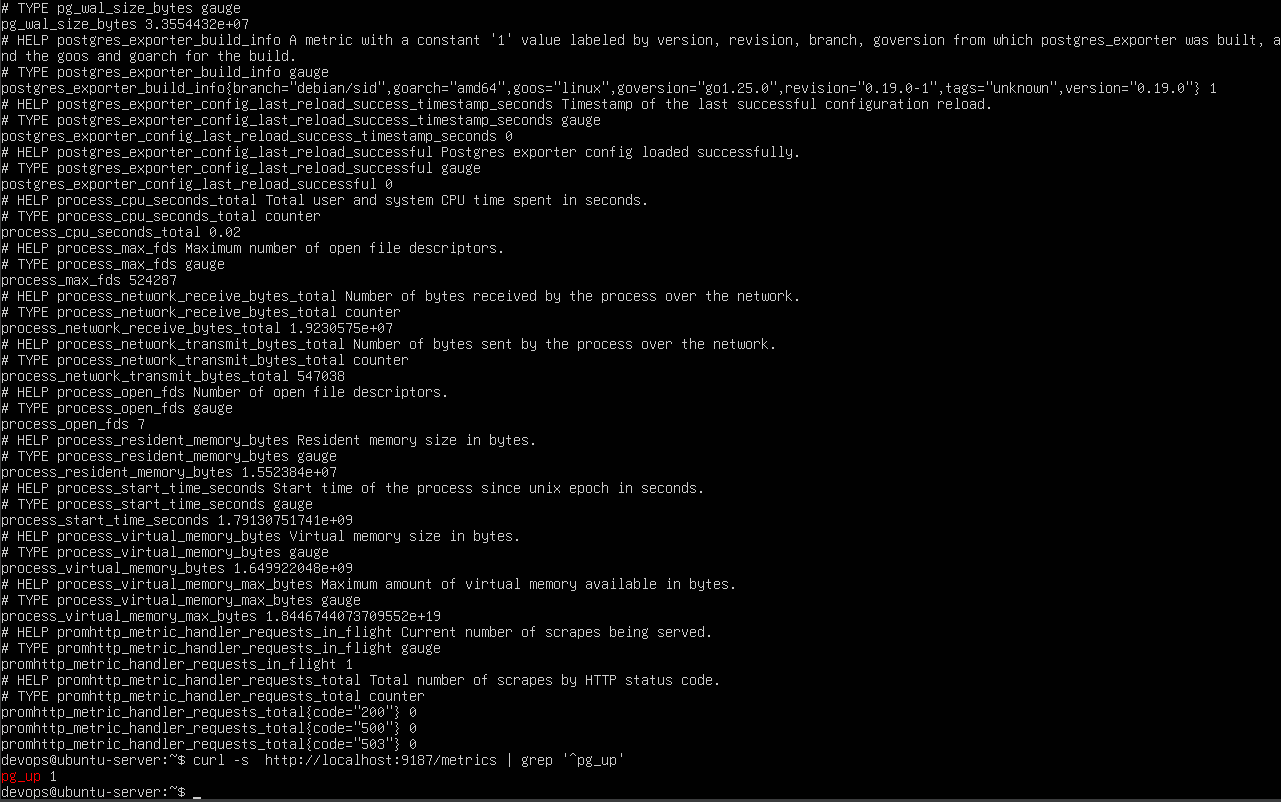